<center>
    <font size="5"> Sieci neuronowe i uczenie głębokie<br/>
        <small><em>Studia stacjonarne II stopnia 2025/2026</em><br/>Kierunek: Matematyka stosowana<br>Specjalność: Analityka danych</small>
    </font>
</center>
<br>



# Laboratorium nr 7: Sieć Hopfielda

### Import bibliotek

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import matplotlib.pyplot as plt

print("Numpy version:", np.__version__)
print("Tensorflow version:", tf.__version__)

2026-04-01 00:57:29.987272: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Numpy version: 2.4.2
Tensorflow version: 2.20.0


## Sieć Hopfielda
Zaimplementuj architekturę sieci Hopfielda wraz z algorytmami uczenia: Hebb, Pseudoinwersja.

- Budowa i działanie sieci: SN_Hopfield.pdf
- Algorytm Hebba i Pseudoinversja: Matusik.pdf

In [2]:
class Hopfield:
    def __init__(self, n):
        self.W = np.zeros((n, n))
        self.n = n
        self.iter = 0

    def predict(self, x, maxiter=10000):
        y = x.copy()
        for _ in range(maxiter):
            self.iter += 1
            for j in range(self.n):
                y[j] = np.sign(np.dot(x, self.W[j]))
                if y[j] == 0:
                    y[j] = x[j]
            if np.all(y == x):
                break
            x = y.copy()
        return y
        # pass

    def train_pseudo_inv(self, X):
        X = np.array(X, dtype=float)
        self.W = X @ np.linalg.inv(X.T @ X) @ X.T
        np.fill_diagonal(self.W, 0)

    def train_iterative(self, X):
        """
        Adaptacja wag metodą iteracyjną:
        W_{i+1} = W_i + ((W_i x_i - x_i)(W_i x_i - x_i)^T) /
                          (x_i^T x_i - x_i^T W_i x_i)
        """
        self.W = np.zeros((self.n, self.n), dtype=float)

        for x in X:
            x = np.array(x, dtype=float).reshape(-1, 1)

            if x.shape[0] != self.n:
                raise ValueError(
                    f"Wektor ma zły rozmiar: {x.shape[0]} zamiast {self.n}"
                )

            diff = self.W @ x - x
            denom = (x.T @ x - x.T @ self.W @ x).item()

            if np.isclose(denom, 0.0):
                continue

            self.W = self.W + (diff @ diff.T) / denom

        np.fill_diagonal(self.W, 0)

## Dane uczące (wzorce).

In [3]:
# cyfry 5x7 pikseli
pattern_data = {
    "0": [
        1,
        1,
        1,
        1,
        1,
        1,
        -1,
        -1,
        -1,
        1,
        1,
        -1,
        -1,
        -1,
        1,
        1,
        -1,
        -1,
        -1,
        1,
        1,
        -1,
        -1,
        -1,
        1,
        1,
        -1,
        -1,
        -1,
        1,
        1,
        1,
        1,
        1,
        1,
    ],
    "1": [
        -1,
        -1,
        -1,
        -1,
        1,
        -1,
        -1,
        -1,
        1,
        1,
        -1,
        -1,
        1,
        -1,
        1,
        -1,
        -1,
        -1,
        -1,
        1,
        -1,
        -1,
        -1,
        -1,
        1,
        -1,
        -1,
        -1,
        -1,
        1,
        -1,
        -1,
        -1,
        -1,
        1,
    ],
    "2": [
        1,
        1,
        1,
        1,
        1,
        -1,
        -1,
        -1,
        -1,
        1,
        -1,
        -1,
        -1,
        -1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        -1,
        -1,
        -1,
        -1,
        1,
        -1,
        -1,
        -1,
        -1,
        1,
        1,
        1,
        1,
        1,
    ],
    "3": [
        1,
        1,
        1,
        1,
        1,
        -1,
        -1,
        -1,
        -1,
        1,
        -1,
        -1,
        -1,
        -1,
        1,
        -1,
        1,
        1,
        1,
        1,
        -1,
        -1,
        -1,
        -1,
        1,
        -1,
        -1,
        -1,
        -1,
        1,
        1,
        1,
        1,
        1,
        1,
    ],
    "4": [
        1,
        -1,
        -1,
        -1,
        -1,
        1,
        -1,
        -1,
        -1,
        -1,
        1,
        -1,
        -1,
        1,
        -1,
        1,
        1,
        1,
        1,
        1,
        -1,
        -1,
        -1,
        1,
        -1,
        -1,
        -1,
        -1,
        1,
        -1,
        -1,
        -1,
        -1,
        1,
        -1,
    ],
    "5": [
        1,
        1,
        1,
        1,
        1,
        1,
        -1,
        -1,
        -1,
        -1,
        1,
        -1,
        -1,
        -1,
        -1,
        1,
        1,
        1,
        1,
        1,
        -1,
        -1,
        -1,
        -1,
        1,
        -1,
        -1,
        -1,
        -1,
        1,
        1,
        1,
        1,
        1,
        1,
    ],
    "6": [
        1,
        1,
        1,
        1,
        1,
        1,
        -1,
        -1,
        -1,
        -1,
        1,
        -1,
        -1,
        -1,
        -1,
        1,
        1,
        1,
        1,
        1,
        1,
        -1,
        -1,
        -1,
        1,
        1,
        -1,
        -1,
        -1,
        1,
        1,
        1,
        1,
        1,
        1,
    ],
    "7": [
        1,
        1,
        1,
        1,
        1,
        -1,
        -1,
        -1,
        -1,
        1,
        -1,
        -1,
        -1,
        1,
        -1,
        -1,
        -1,
        1,
        -1,
        -1,
        -1,
        1,
        -1,
        -1,
        -1,
        1,
        -1,
        -1,
        -1,
        -1,
        1,
        -1,
        -1,
        -1,
        -1,
    ],
    "8": [
        1,
        1,
        1,
        1,
        1,
        1,
        -1,
        -1,
        -1,
        1,
        1,
        -1,
        -1,
        -1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        -1,
        -1,
        -1,
        1,
        1,
        -1,
        -1,
        -1,
        1,
        1,
        1,
        1,
        1,
        1,
    ],
    "9": [
        1,
        1,
        1,
        1,
        1,
        1,
        -1,
        -1,
        -1,
        1,
        1,
        -1,
        -1,
        -1,
        1,
        1,
        1,
        1,
        1,
        1,
        -1,
        -1,
        -1,
        -1,
        1,
        -1,
        -1,
        -1,
        -1,
        1,
        1,
        1,
        1,
        1,
        1,
    ],
}

In [4]:
def plot_images(images, no_r=2, no_c=5, figsize=(4, 4)):
    fig = plt.figure(figsize=figsize)
    images = np.array(images).reshape(-1, 7, 5)
    for i in range(no_r):
        for j in range(no_c):
            ax = fig.add_subplot(no_r, no_c, no_c * i + (j + 1))
            ax.matshow(images[no_c * i + j], cmap="gray")
            plt.xticks(np.array([]))
            plt.yticks(np.array([]))

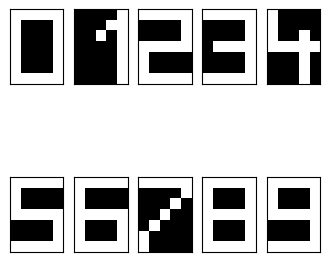

In [5]:
train_data = [np.array(d) for d in pattern_data.values()]
plot_images(train_data, no_r=2, no_c=5)

## Trenowanie
Utwórz instancje sieci Hipfielda i ją wytrenuj

In [7]:
hopf = Hopfield(7 * 5)
hopf.train_iterative(np.array(train_data))

## Testowanie
Przygotuj przykłady testowe (np. takie jak w pdf'ie) i zaprezentuj wyniki.

In [8]:
test = (
    [
        1,
        1,
        1,
        -1,
        1,
        1,
        -1,
        1,
        -1,
        1,
        1,
        -1,
        -1,
        -1,
        1,
        1,
        -1,
        1,
        1,
        1,
        -1,
        -1,
        -1,
        -1,
        1,
        -1,
        -1,
        -1,
        -1,
        1,
        1,
        1,
        1,
        1,
        1,
    ],
)

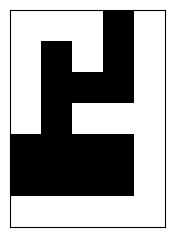

In [9]:
plot_images([np.array(test[0])], no_r=1, no_c=1, figsize=(2, 3))

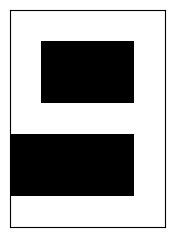

In [10]:
pred = hopf.predict(test[0])
plot_images([np.array(pred)], no_r=1, no_c=1, figsize=(2, 3))

In [11]:
hopf_pseudoinv = Hopfield(35)
hopf_pseudoinv.train_iterative(np.array(train_data))

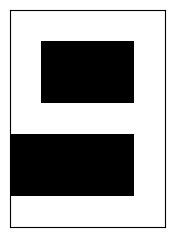

In [12]:
pred = hopf_pseudoinv.predict(test[0])
plot_images([np.array(pred)], no_r=1, no_c=1, figsize=(2, 3))

## Odszumianie danych
Przygotuje kod zaszumiający wzorce uczące, mutacja piksela z ustalonym prawdopodobieństwem. Przeprowadź eksperymenty pokazujące zdolność sieci Hopfielda od odszumiania danych.

In [13]:
def add_noise(x, noise_level):
    """
    noise_level: float w zakresie [0, 1]
        np. 0.1 = 10% bitów zostanie odwróconych
    """
    x = np.array(x).copy()
    n = len(x)

    k = int(noise_level * n)  # ile bitów zmienić
    idx = np.random.choice(n, size=k, replace=False)

    x[idx] *= -1  # flip znaków
    return x


def generate_noisy_dataset(pattern_data, noise_levels, samples_per_level=5):
    """
    noise_levels: lista np. [0.0, 0.1, 0.2, 0.3]
    samples_per_level: ile zaszumionych wersji na poziom

    Zwraca:
        dict: {cyfra: {noise_level: [wektory]}}
    """
    result = {}

    for digit, pattern in pattern_data.items():
        result[digit] = {}

        for nl in noise_levels:
            noisy_versions = []
            for _ in range(samples_per_level):
                noisy = add_noise(pattern, nl)
                noisy_versions.append(noisy)

            result[digit][nl] = noisy_versions

    return result


noise_levels = [0.0, 0.1, 0.2, 0.3, 0.4]

noisy_data = generate_noisy_dataset(pattern_data, noise_levels)

# przykład: zaszumione "5" na poziomie 30%
example = noisy_data["5"][0.3][0]
print(example)

[ 1  1 -1  1  1  1  1 -1 -1 -1 -1  1  1  1 -1  1  1  1  1 -1 -1 -1 -1  1
  1  1 -1 -1 -1  1  1 -1  1  1  1]


In [14]:
def generate_n_noisy_random_noise(pattern_data, N, noise_range=(0.0, 0.4)):
    digits = list(pattern_data.keys())
    result = []

    for _ in range(N):
        d = np.random.choice(digits)
        clean = np.array(pattern_data[d])

        noise_level = np.random.uniform(*noise_range)
        noisy = add_noise(clean, noise_level)

        result.append((d, noisy, noise_level))

    return result

In [15]:
def generate_balanced_noisy(pattern_data, samples_per_digit, noise_level):
    result = []

    for d, pattern in pattern_data.items():
        for _ in range(samples_per_digit):
            clean = np.array(pattern)
            noisy = add_noise(clean, noise_level)
            result.append((d, noisy))

    return result

In [ ]:
data = generate_balanced_noisy(pattern_data, samples_per_digit=3, noise_level=0.1)

/tmp/ipykernel_1482/3834213010.py:9: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(3, 4))


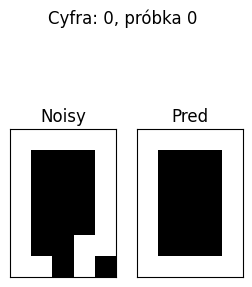

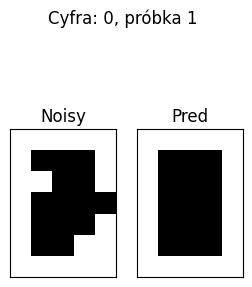

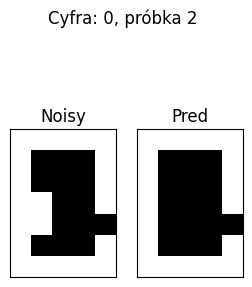

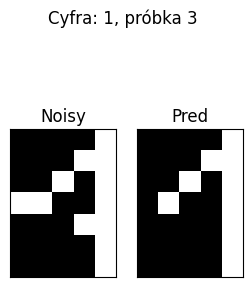

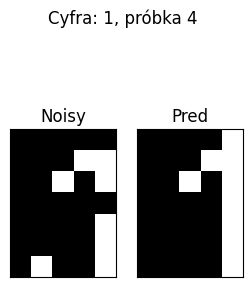

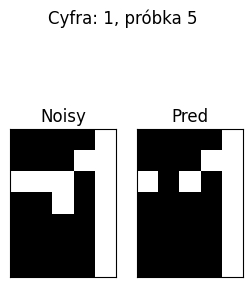

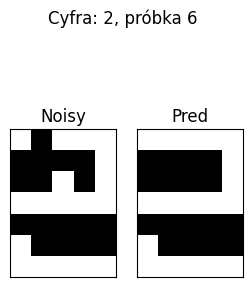

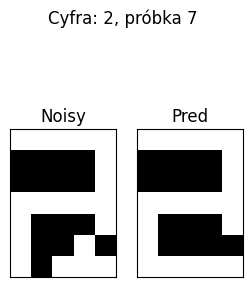

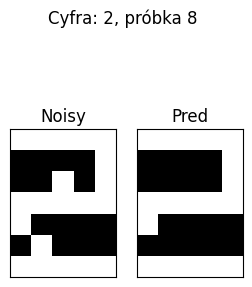

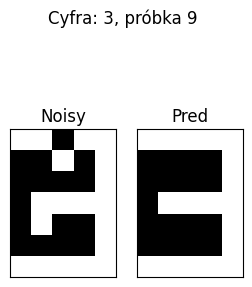

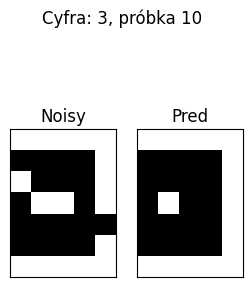

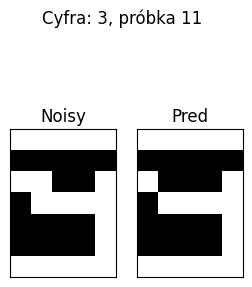

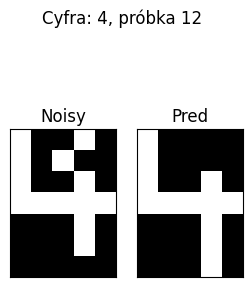

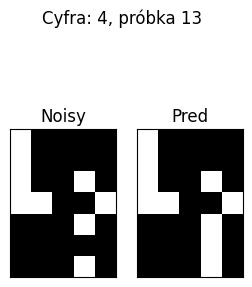

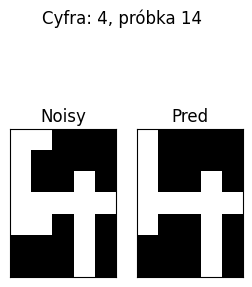

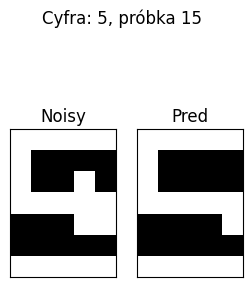

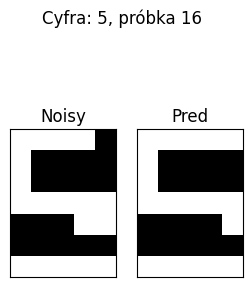

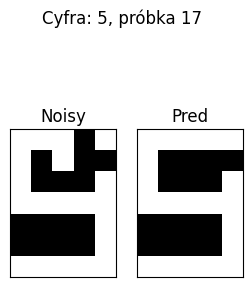

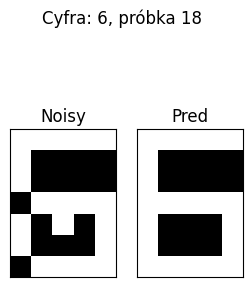

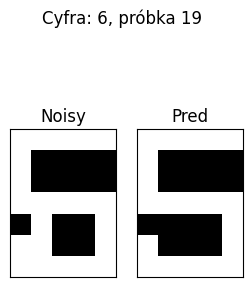

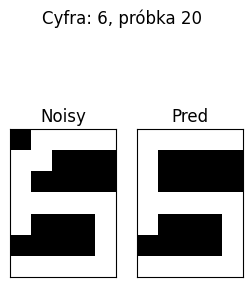

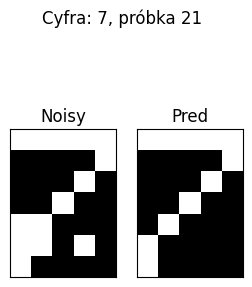

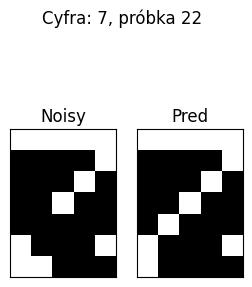

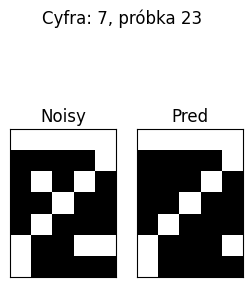

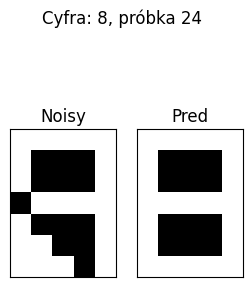

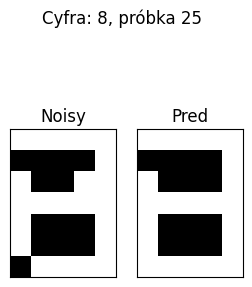

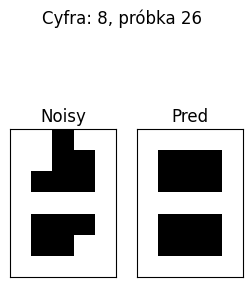

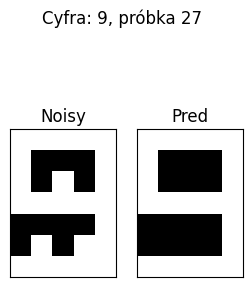

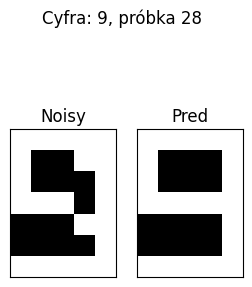

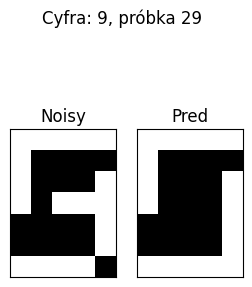

Accuracy: 0.36666666666666664


In [17]:
correct = 0

for idx, (label, noisy) in enumerate(data):
    pred = hopf_pseudoinv.predict(noisy.copy())
    if np.array_equal(pred, pattern_data[label]):
        correct += 1

    # rysowanie: zaszumiony vs zrekonstruowany
    fig = plt.figure(figsize=(3, 4))
    fig.suptitle(f"Cyfra: {label}, próbka {idx}")

    ax1 = fig.add_subplot(1, 2, 1)
    ax1.set_title("Noisy")
    ax1.matshow(noisy.reshape(7, 5), cmap="gray")
    ax1.set_xticks([])
    ax1.set_yticks([])

    ax2 = fig.add_subplot(1, 2, 2)
    ax2.set_title("Pred")
    ax2.matshow(pred.reshape(7, 5), cmap="gray")
    ax2.set_xticks([])
    ax2.set_yticks([])

plt.show()
print("Accuracy:", correct / len(data))

### Odtwarzenie obrazu z fragmentu
Przygotuj obraz, wylicz wagi i sprawdz czy sieć jest w stanie go odtworzyć z fragmentu.

In [18]:
import imageio.v3 as iio

im = iio.imread("images.png", mode="L")
im = im[20:-20, 65:-60]
im = np.where(im < 128, -1, 1)

In [19]:
im.shape

(143, 150)

([], [])

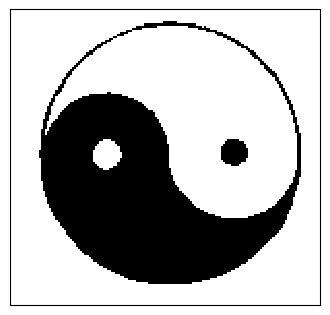

In [20]:
fig = plt.figure(figsize=(4, 5))
ax = fig.add_subplot(1, 1, 1)
ax.matshow(im, cmap="gray")
plt.xticks(np.array([]))
plt.yticks(np.array([]))

In [21]:
hopf_yingyang = Hopfield(143 * 150)
hopf_yingyang.train_iterative(im.reshape(1, -1))

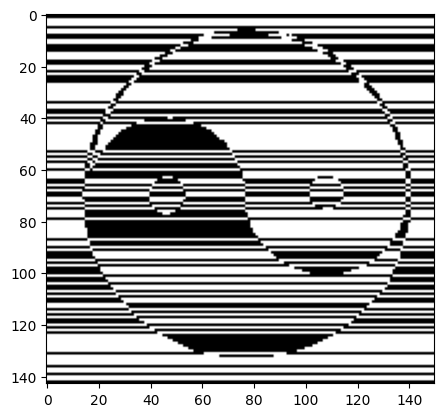

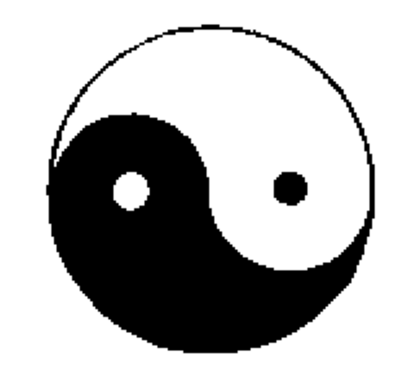

In [22]:
test = add_noise(im, 0.4)

pred = hopf_yingyang.predict(im.reshape(-1))

pred_img = pred.reshape(im.shape)

plt.imshow((test + 1) / 2, cmap="gray")
plt.show()
plt.imshow((pred_img + 1) / 2, cmap="gray")
plt.axis("off")
plt.show()